In [17]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path.cwd().parent

INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

input_path = INTERIM_DATA_DIR / "geolife_gps_osm_features.parquet"

df = pd.read_parquet(input_path)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Shape: (916, 14)
Columns:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


In [18]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (916, 14)

Data types:
guard_id                            object
timestamp                   datetime64[ns]
latitude                           float64
longitude                          float64
altitude_ft                          int64
time_gap_seconds                   float64
distance_from_previous_m           float64
speed_kmh                          float64
gps_jump                              bool
distance_to_road_m                 float64
road_match_status                 category
highway                             object
maxspeed                            object
length                             float64
dtype: object

First 5 rows:


,guard_id,timestamp,latitude,longitude,altitude_ft,time_gap_seconds,distance_from_previous_m,speed_kmh,gps_jump,distance_to_road_m,road_match_status,highway,maxspeed,length
0,000,2008-10-23 02:53:04,39.984702,116.318417,492,NaN,0.000000,NaN,False,5.513269,GOOD,tertiary,None,401.0
1,000,2008-10-23 02:53:10,39.984683,116.318450,492,6.0,3.520694,2.112417,False,3.297444,GOOD,tertiary,None,401.0
2,000,2008-10-23 02:53:15,39.984686,116.318417,492,5.0,2.838241,2.043534,False,3.738673,GOOD,tertiary,None,401.0
3,000,2008-10-23 02:53:20,39.984688,116.318385,492,5.0,2.742220,1.974399,False,4.065703,GOOD,tertiary,None,401.0
4,000,2008-10-23 02:53:25,39.984655,116.318263,492,5.0,11.045822,7.952992,False,0.806703,GOOD,tertiary,None,401.0


In [19]:
numeric_cols = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length"
]

print(
    df[numeric_cols].describe().T
)

                          count        mean         std       min        25%  \
time_gap_seconds          915.0   32.724590  624.355707  1.000000   5.000000   
distance_from_previous_m  916.0   16.392717   84.842050  0.000000   4.665800   
speed_kmh                 915.0    8.049921   10.079986  0.000000   3.270079   
distance_to_road_m        916.0   13.579800   16.865519  0.007636   3.327606   
length                    916.0  453.228166  444.002808  9.000000  95.000000   

                                 50%         75%           max  
time_gap_seconds            5.000000    5.000000  18453.000000  
distance_from_previous_m   10.494398   16.027460   1817.893113  
speed_kmh                   7.307210   11.412784    218.147174  
distance_to_road_m          7.186341   15.369943     73.486863  
length                    345.000000  535.000000   1711.000000  


In [20]:
print("\nCategorical distributions:")

for col in [
    "road_match_status",
    "highway",
    "gps_jump"
]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


Categorical distributions:

--- road_match_status ---
road_match_status
GOOD          568
ACCEPTABLE    227
VERY_FAR       70
FAR            51
Name: count, dtype: int64

--- highway ---
highway
residential      250
footway          229
tertiary         157
path             114
service           60
secondary         53
primary           31
steps              6
trunk              6
tertiary_link      6
unclassified       2
trunk_link         2
Name: count, dtype: int64

--- gps_jump ---
gps_jump
False    915
True       1
Name: count, dtype: int64


In [3]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

# Guard Wise Sorting

In [5]:
df = df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)
print(
    df[
        ["guard_id", "timestamp"]
    ].head(20)
)

   guard_id           timestamp
0       000 2008-10-23 02:53:04
1       000 2008-10-23 02:53:10
2       000 2008-10-23 02:53:15
3       000 2008-10-23 02:53:20
4       000 2008-10-23 02:53:25
5       000 2008-10-23 02:53:30
6       000 2008-10-23 02:53:35
7       000 2008-10-23 02:53:40
8       000 2008-10-23 02:53:45
9       000 2008-10-23 02:53:50
10      000 2008-10-23 02:53:55
11      000 2008-10-23 02:54:00
12      000 2008-10-23 02:54:05
13      000 2008-10-23 02:54:10
14      000 2008-10-23 02:54:15
15      000 2008-10-23 02:54:20
16      000 2008-10-23 02:54:25
17      000 2008-10-23 02:54:30
18      000 2008-10-23 02:54:35
19      000 2008-10-23 02:54:40


# Existing features identify karo

In [6]:
feature_columns = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "gps_jump",
    "distance_to_road_m",
    "road_match_status",
    "length"]
print(
    df[feature_columns].describe(include="all"))

        time_gap_seconds  distance_from_previous_m   speed_kmh gps_jump  \
count         915.000000                916.000000  915.000000      916   
unique               NaN                       NaN         NaN        2   
top                  NaN                       NaN         NaN    False   
freq                 NaN                       NaN         NaN      915   
mean           32.724590                 16.392717    8.049921      NaN   
std           624.355707                 84.842050   10.079986      NaN   
min             1.000000                  0.000000    0.000000      NaN   
25%             5.000000                  4.665800    3.270079      NaN   
50%             5.000000                 10.494398    7.307210      NaN   
75%             5.000000                 16.027460   11.412784      NaN   
max         18453.000000               1817.893113  218.147174      NaN   

        distance_to_road_m road_match_status       length  
count           916.000000             

# Numeric Correlation 

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
numeric_features = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length"]
correlation = df[numeric_features].corr()
print(correlation.round(2))

                          time_gap_seconds  distance_from_previous_m  \
time_gap_seconds                      1.00                      0.39   
distance_from_previous_m              0.39                      1.00   
speed_kmh                            -0.03                      0.55   
distance_to_road_m                   -0.03                     -0.02   
length                               -0.02                     -0.03   

                          speed_kmh  distance_to_road_m  length  
time_gap_seconds              -0.03               -0.03   -0.02  
distance_from_previous_m       0.55               -0.02   -0.03  
speed_kmh                      1.00               -0.10    0.08  
distance_to_road_m            -0.10                1.00   -0.20  
length                         0.08               -0.20    1.00  


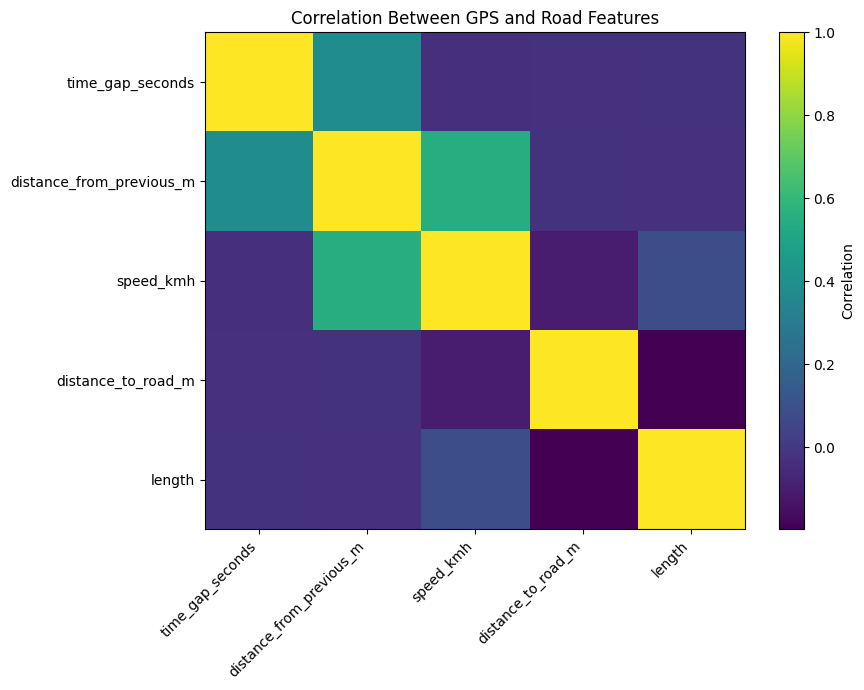

In [22]:
# Visualization 
plt.figure(figsize=(9, 7))
plt.imshow(
    correlation,
    aspect="auto")
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right")
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns)
plt.colorbar(label="Correlation")
plt.title("Correlation Between GPS and Road Features")
plt.tight_layout()
plt.show()

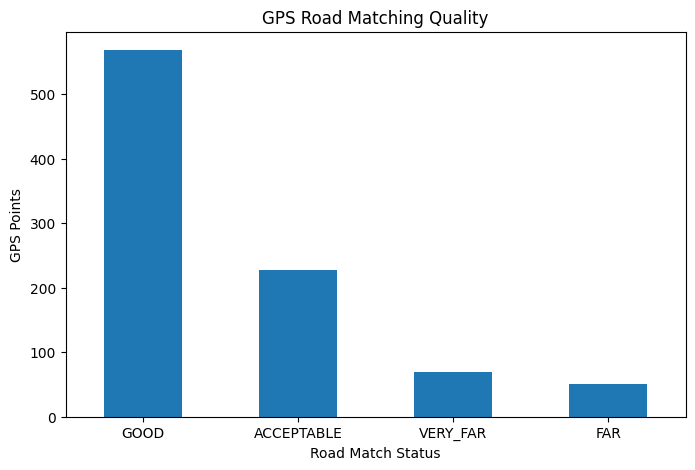

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

df["road_match_status"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Road Match Status")
plt.ylabel("GPS Points")
plt.title("GPS Road Matching Quality")

plt.xticks(rotation=0)

plt.show()

## High Way Type Analysis 

In [24]:
highway_counts = (
    df["highway"]
    .value_counts()
    .head(15))
print(highway_counts)

highway
residential      250
footway          229
tertiary         157
path             114
service           60
secondary         53
primary           31
steps              6
trunk              6
tertiary_link      6
unclassified       2
trunk_link         2
Name: count, dtype: int64


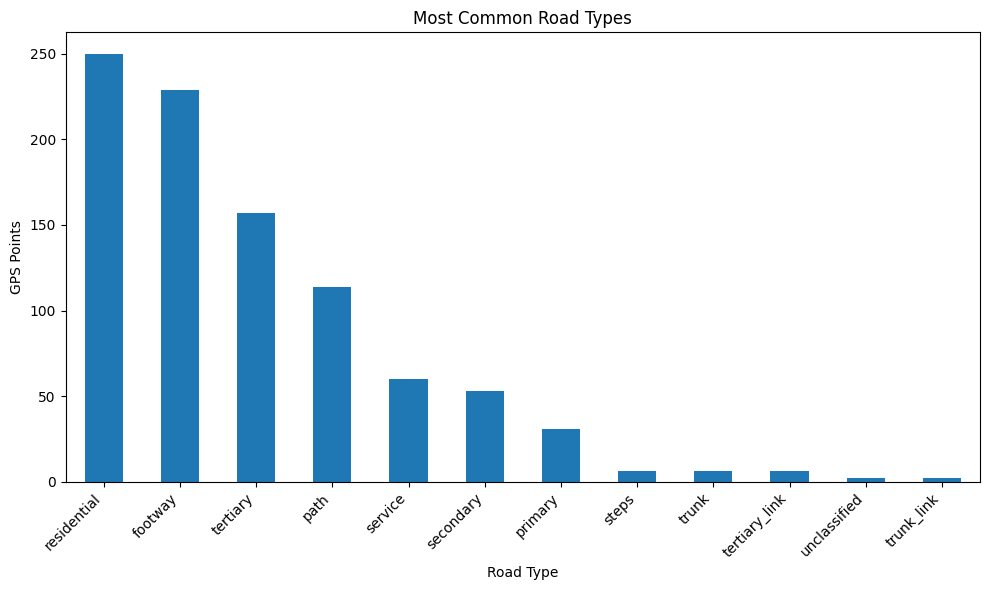

In [25]:
plt.figure(figsize=(10, 6))
highway_counts.plot(
    kind="bar")
plt.xlabel("Road Type")
plt.ylabel("GPS Points")
plt.title("Most Common Road Types")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Important Anomaly Candidates

In [26]:
anomaly_candidates = df[
    (df["speed_kmh"] > 100) |
    (df["time_gap_seconds"] > 3600) |
    (df["distance_to_road_m"] > 50) |
    (df["gps_jump"] == True)]
print("Potential anomaly candidates:", len(anomaly_candidates))
display(
    anomaly_candidates[
        [
            "guard_id",
            "timestamp",
            "time_gap_seconds",
            "distance_from_previous_m",
            "speed_kmh",
            "gps_jump",
            "distance_to_road_m",
            "road_match_status"
        ]
    ].head(20))

Potential anomaly candidates: 74


,guard_id,timestamp,time_gap_seconds,distance_from_previous_m,speed_kmh,gps_jump,distance_to_road_m,road_match_status
148,000,2008-10-23 04:08:07,3772.0,1652.669139,1.577309,False,10.987361,ACCEPTABLE
149,000,2008-10-23 04:08:12,5.0,164.477469,118.423778,False,1.506708,GOOD
150,000,2008-10-23 04:08:42,30.0,1817.893113,218.147174,True,6.030698,GOOD
470,000,2008-10-23 09:42:25,18453.0,686.989499,0.134025,False,0.007636,GOOD
650,000,2008-10-23 10:06:44,5.0,14.379006,10.352884,False,52.073291,VERY_FAR
651,000,2008-10-23 10:06:49,5.0,5.073659,3.653034,False,56.138074,VERY_FAR
652,000,2008-10-23 10:06:52,3.0,0.000000,0.000000,False,56.138074,VERY_FAR
653,000,2008-10-23 10:06:54,2.0,0.339012,0.610222,False,56.346373,VERY_FAR
654,000,2008-10-23 10:06:59,5.0,8.529170,6.141002,False,61.088165,VERY_FAR
655,000,2008-10-23 10:07:04,5.0,12.080632,8.698055,False,63.132572,VERY_FAR


In [ ]:
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["day_of_week"] = df["timestamp"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

df["is_night"] = (
    (df["hour"] < 6) |
    (df["hour"] >= 22)
).astype(int)
print(
    df[
        [
            "timestamp",
            "hour",
            "minute",
            "day_of_week",
            "is_weekend",
            "is_night"]].head(10))

            timestamp  hour  minute  day_of_week  is_weekend  is_night
0 2008-10-23 02:53:04     2      53            3           0         1
1 2008-10-23 02:53:10     2      53            3           0         1
2 2008-10-23 02:53:15     2      53            3           0         1
3 2008-10-23 02:53:20     2      53            3           0         1
4 2008-10-23 02:53:25     2      53            3           0         1
5 2008-10-23 02:53:30     2      53            3           0         1
6 2008-10-23 02:53:35     2      53            3           0         1
7 2008-10-23 02:53:40     2      53            3           0         1
8 2008-10-23 02:53:45     2      53            3           0         1
9 2008-10-23 02:53:50     2      53            3           0         1


# GPS movement Features

In [28]:
df["speed_deviation_from_normal"] = (
    df["speed_kmh"] - df["speed_kmh"].median())
df["distance_deviation_from_normal"] = (
    df["distance_from_previous_m"]
    - df["distance_from_previous_m"].median())
df["road_distance_ratio"] = (
    df["distance_to_road_m"] /
    (df["distance_from_previous_m"] + 1))

# Suspicious GPS Movement Flags

In [29]:
df["high_speed_flag"] = (
    df["speed_kmh"] > 30
).astype(int)
df["large_road_distance_flag"] = (
    df["distance_to_road_m"] > 50
).astype(int)
df["long_time_gap_flag"] = (
    df["time_gap_seconds"] > 300
).astype(int)

# Combined Behavioral Indicator

In [30]:
df["movement_risk_indicator"] = (
    df["high_speed_flag"]
    + df["large_road_distance_flag"]
    + df["long_time_gap_flag"]
    + df["gps_jump"].astype(int))

# Check ENgineered Features

In [37]:
new_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "is_night",
    "speed_deviation_from_normal",
    "distance_deviation_from_normal",
    "road_distance_ratio",
    "high_speed_flag",
    "large_road_distance_flag",
    "long_time_gap_flag",
    "movement_risk_indicator"
]

print(df[new_features].describe())

             hour  day_of_week  is_weekend    is_night  \
count  916.000000        916.0       916.0  916.000000   
mean     6.534934          3.0         0.0    0.513100   
std      3.177772          0.0         0.0    0.500101   
min      2.000000          3.0         0.0    0.000000   
25%      4.000000          3.0         0.0    0.000000   
50%      4.000000          3.0         0.0    1.000000   
75%     10.000000          3.0         0.0    1.000000   
max     11.000000          3.0         0.0    1.000000   

       speed_deviation_from_normal  distance_deviation_from_normal  \
count                   915.000000                      916.000000   
mean                      0.742711                        5.898319   
std                      10.079986                       84.842050   
min                      -7.307210                      -10.494398   
25%                      -4.037132                       -5.828598   
50%                       0.000000                       

In [38]:
print(df[new_features].head(20))

    hour  day_of_week  is_weekend  is_night  speed_deviation_from_normal  \
0      2            3           0         1                          NaN   
1      2            3           0         1                    -5.194794   
2      2            3           0         1                    -5.263676   
3      2            3           0         1                    -5.332812   
4      2            3           0         1                     0.645782   
5      2            3           0         1                     7.686129   
6      2            3           0         1                     8.991360   
7      2            3           0         1                     8.123379   
8      2            3           0         1                     6.540284   
9      2            3           0         1                     7.759912   
10     2            3           0         1                     2.638698   
11     2            3           0         1                     4.770814   
12     2    

In [ ]:
df = df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)
print(
    df[
        ["guard_id", "timestamp", "speed_kmh", "distance_to_road_m"]
    ].head(10))

  guard_id           timestamp  speed_kmh  distance_to_road_m
0      000 2008-10-23 02:53:04        NaN            5.513269
1      000 2008-10-23 02:53:10   2.112417            3.297444
2      000 2008-10-23 02:53:15   2.043534            3.738673
3      000 2008-10-23 02:53:20   1.974399            4.065703
4      000 2008-10-23 02:53:25   7.952992            0.806703
5      000 2008-10-23 02:53:30  14.993339            3.294199
6      000 2008-10-23 02:53:35  16.298570            2.755575
7      000 2008-10-23 02:53:40  15.430589            6.907046
8      000 2008-10-23 02:53:45  13.847494            8.792879
9      000 2008-10-23 02:53:50  15.067123            0.565673


# Rolling Average Speed 

In [41]:
df["rolling_speed_mean_5"] = (
    df.groupby("guard_id")["speed_kmh"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).mean()))

It will calculate the **average speed of the last 5 GPS observations around each point**.

# Rolling Speed Variability 

In [ ]:
df["rolling_speed_std_5"] = (
    df.groupby("guard_id")["speed_kmh"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=2
          ).std()
      ).fillna(0))

# Rolling Road Distance 

In [42]:
df["rolling_road_distance_mean_5"] = (
    df.groupby("guard_id")["distance_to_road_m"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).mean()))

# Recent GPS Jump Count

In [43]:
df["rolling_gps_jump_count_5"] = (
    df.groupby("guard_id")["gps_jump"]
      .transform(
          lambda x: x.astype(int)
          .rolling(
              window=5,
              min_periods=1
          ).sum()))

# Recent Long Time Gap Count

In [44]:
df["rolling_long_gap_count_5"] = (
    df.groupby("guard_id")["long_time_gap_flag"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).sum() ))

In [46]:
df["rolling_speed_std_5"] = (
    df.groupby("guard_id")["speed_kmh"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=2
          ).std()
      )
      .fillna(0))

# Check Features

In [47]:
rolling_features = [
    "rolling_speed_mean_5",
    "rolling_speed_std_5",
    "rolling_road_distance_mean_5",
    "rolling_gps_jump_count_5",
    "rolling_long_gap_count_5"]
print(
    df[
        ["guard_id", "timestamp"] + rolling_features
    ].head(20))

   guard_id           timestamp  rolling_speed_mean_5  rolling_speed_std_5  \
0       000 2008-10-23 02:53:04                   NaN             0.000000   
1       000 2008-10-23 02:53:10              2.112417             0.000000   
2       000 2008-10-23 02:53:15              2.077975             0.048707   
3       000 2008-10-23 02:53:20              2.043450             0.069009   
4       000 2008-10-23 02:53:25              3.520835             2.955308   
5       000 2008-10-23 02:53:30              5.815336             5.733590   
6       000 2008-10-23 02:53:35              8.652567             6.845316   
7       000 2008-10-23 02:53:40             11.329978             6.201875   
8       000 2008-10-23 02:53:45             13.704597             3.334291   
9       000 2008-10-23 02:53:50             15.127423             0.883647   
10      000 2008-10-23 02:53:55             14.117937             2.492897   
11      000 2008-10-23 02:54:00             13.273828           

In [32]:
df["speed_change_kmh"] = (
    df.groupby("guard_id")["speed_kmh"]
      .diff())

In [33]:
df["speed_change_kmh"] = (
    df.groupby("guard_id")["speed_kmh"]
      .diff())

In [34]:
df.loc[
    df["time_gap_seconds"] <= 0,
    "acceleration_kmh_per_sec"
] = np.nan

In [35]:
df["route_deviation_m"] = df["distance_to_road_m"]

In [36]:
road_status_map = {
    "GOOD": 0,
    "ACCEPTABLE": 1,
    "FAR": 2,
    "VERY_FAR": 3}
df["road_deviation_score"] = (
    df["road_match_status"]
    .map(road_status_map))

# Correlation Check 

In [48]:
corr_features = [
    "speed_kmh",
    "distance_from_previous_m",
    "distance_to_road_m",
    "time_gap_seconds",
    "rolling_speed_mean_5",
    "rolling_speed_std_5",
    "rolling_road_distance_mean_5",
    "movement_risk_indicator"]
corr = df[corr_features].corr()
print(corr.round(2))

                              speed_kmh  distance_from_previous_m  \
speed_kmh                          1.00                      0.55   
distance_from_previous_m           0.55                      1.00   
distance_to_road_m                -0.10                     -0.02   
time_gap_seconds                  -0.03                      0.39   
rolling_speed_mean_5               0.56                      0.28   
rolling_speed_std_5                0.42                      0.29   
rolling_road_distance_mean_5      -0.12                     -0.03   
movement_risk_indicator            0.22                      0.27   

                              distance_to_road_m  time_gap_seconds  \
speed_kmh                                  -0.10             -0.03   
distance_from_previous_m                   -0.02              0.39   
distance_to_road_m                          1.00             -0.03   
time_gap_seconds                           -0.03              1.00   
rolling_speed_mean_5        

# Verify Rolling Features 

In [50]:
rolling_features = [
    "rolling_speed_mean_5",
    "rolling_speed_std_5",
    "rolling_road_distance_mean_5",
    "rolling_gps_jump_count_5",
    "rolling_long_gap_count_5"]
available_features = [
    col for col in rolling_features
    if col in df.columns]
missing_features = [
    col for col in rolling_features
    if col not in df.columns]
print("Available rolling features:")
print(available_features)
print("\nMissing rolling features:")
print(missing_features)
print(
    df[
        ["guard_id", "timestamp"] + rolling_features
    ].head(20)
)

Available rolling features:
['rolling_speed_mean_5', 'rolling_speed_std_5', 'rolling_road_distance_mean_5', 'rolling_gps_jump_count_5', 'rolling_long_gap_count_5']

Missing rolling features:
[]
   guard_id           timestamp  rolling_speed_mean_5  rolling_speed_std_5  \
0       000 2008-10-23 02:53:04                   NaN             0.000000   
1       000 2008-10-23 02:53:10              2.112417             0.000000   
2       000 2008-10-23 02:53:15              2.077975             0.048707   
3       000 2008-10-23 02:53:20              2.043450             0.069009   
4       000 2008-10-23 02:53:25              3.520835             2.955308   
5       000 2008-10-23 02:53:30              5.815336             5.733590   
6       000 2008-10-23 02:53:35              8.652567             6.845316   
7       000 2008-10-23 02:53:40             11.329978             6.201875   
8       000 2008-10-23 02:53:45             13.704597             3.334291   
9       000 2008-10-23 02:

# Anomaly Features

In [51]:
df["long_time_gap"] = (
    df["time_gap_seconds"] > 300
)   #300 seconds = 5 minutes.

# High-speed anomaly 

In [52]:
df["high_speed"] = (
    df["speed_kmh"] > 60)

# Road Deviation

In [53]:
df["road_deviation"] = (
    df["distance_to_road_m"] > 50)

# GPS Jump

In [54]:
df["gps_jump"]

0      False
1      False
2      False
3      False
4      False
       ...  
911    False
912    False
913    False
914    False
915    False
Name: gps_jump, Length: 916, dtype: bool

# Combined rule anomaly score

In [56]:
df["rule_anomaly_count"] = (
    df["long_time_gap"].astype(int)
    + df["high_speed"].astype(int)
    + df["road_deviation"].astype(int)
    + df["gps_jump"].astype(int))
print(
    df["rule_anomaly_count"]
    .value_counts()
    .sort_index())

rule_anomaly_count
0    837
1     77
2      2
Name: count, dtype: int64


# Behavioral feature relationship

In [57]:
behavior_features = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "rolling_speed_mean_5",
    "rolling_speed_std_5",
    "rolling_road_distance_mean_5",
    "rolling_gps_jump_count_5",
    "rolling_long_gap_count_5"
]
corr = df[behavior_features].corr()
print(corr.round(2))

                              time_gap_seconds  distance_from_previous_m  \
time_gap_seconds                          1.00                      0.39   
distance_from_previous_m                  0.39                      1.00   
speed_kmh                                -0.03                      0.55   
distance_to_road_m                       -0.03                     -0.02   
rolling_speed_mean_5                     -0.02                      0.28   
rolling_speed_std_5                      -0.00                      0.29   
rolling_road_distance_mean_5             -0.02                     -0.03   
rolling_gps_jump_count_5                 -0.00                      0.31   
rolling_long_gap_count_5                  0.24                      0.33   

                              speed_kmh  distance_to_road_m  \
time_gap_seconds                  -0.03               -0.03   
distance_from_previous_m           0.55               -0.02   
speed_kmh                          1.00           

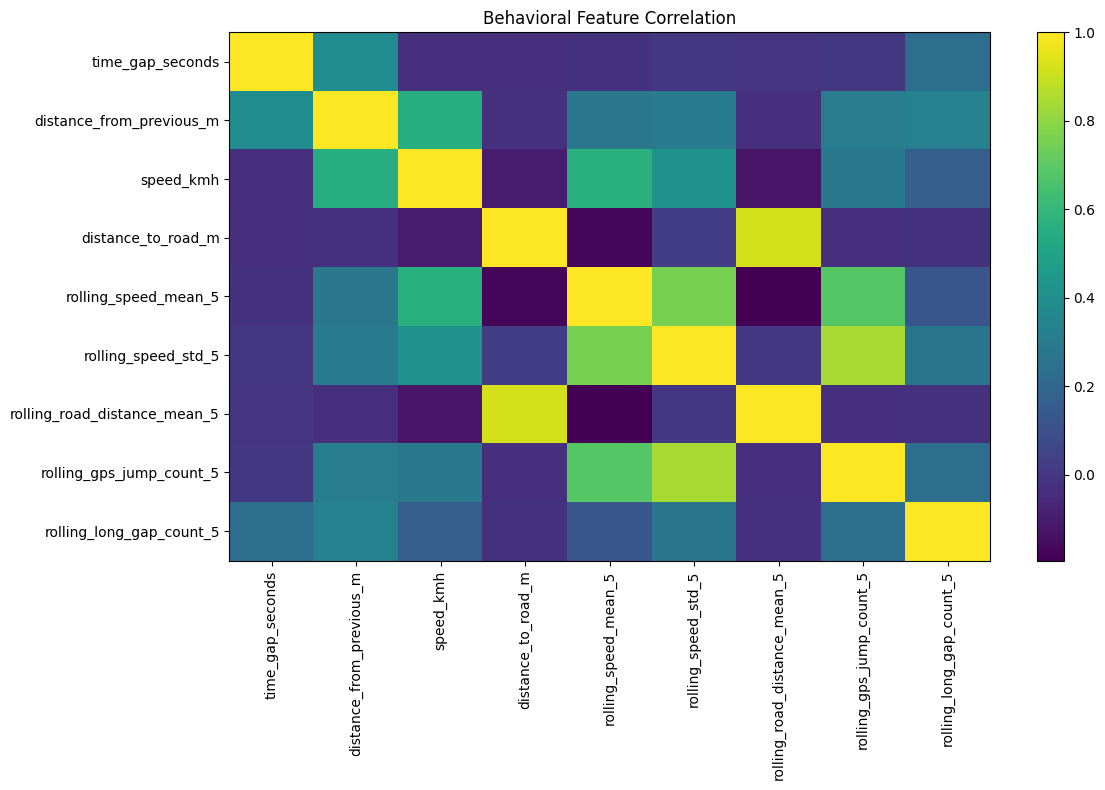

In [58]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.imshow(
    corr,
    aspect="auto")
plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90)
plt.yticks(
    range(len(corr.columns)),
    corr.columns)
plt.title("Behavioral Feature Correlation")
plt.tight_layout()
plt.show()

# Save Features Dataset

In [59]:
feature_output_path = (
    PROCESSED_DATA_DIR /
    "geolife_guard_behavior_features.parquet")
df.to_parquet(
    feature_output_path,
    index=False)
print("Saved:")
print(feature_output_path)
print("Shape:", df.shape)

Saved:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_guard_behavior_features.parquet
Shape: (916, 39)


## Feature Selection 

In [60]:
from pathlib import Path
import pandas as pd
import numpy as np
PROJECT_DIR = Path.cwd().parent
PROCESSED_DATA_DIR = (
    PROJECT_DIR / "data" / "processed")
input_path = (
    PROCESSED_DATA_DIR /
    "geolife_guard_behavior_features.parquet")
df = pd.read_parquet(input_path)
print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (916, 39)
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_night', 'speed_deviation_from_normal', 'distance_deviation_from_normal', 'road_distance_ratio', 'high_speed_flag', 'large_road_distance_flag', 'long_time_gap_flag', 'movement_risk_indicator', 'speed_change_kmh', 'acceleration_kmh_per_sec', 'route_deviation_m', 'road_deviation_score', 'rolling_speed_mean_5', 'rolling_road_distance_mean_5', 'rolling_gps_jump_count_5', 'rolling_long_gap_count_5', 'rolling_speed_std_5', 'long_time_gap', 'high_speed', 'road_deviation', 'rule_anomaly_count']


# Divide Features Into Categories

In [61]:
feature_groups = {
    "identity": [
        "guard_id",
        "timestamp"
    ],
    "location": [
        "latitude",
        "longitude",
        "altitude_ft"
    ],
    "movement": [
        "time_gap_seconds",
        "distance_from_previous_m",
        "speed_kmh"
    ],
    "gps_quality": [
        "gps_jump",
        "distance_to_road_m",
        "road_match_status"
    ],
    "road_context": [
        "highway",
        "length"
    ],
    "behavioral": [
        "rolling_speed_mean_5",
        "rolling_speed_std_5",
        "rolling_road_distance_mean_5",
        "rolling_gps_jump_count_5",
        "rolling_long_gap_count_5"
    ],
    "rule_signals": [
        "long_time_gap",
        "high_speed",
        "road_deviation",
        "rule_anomaly_count"
    ]}
for group, features in feature_groups.items():
    available = [
        col for col in features
        if col in df.columns]
    print(f"\n{group}:")
    print(available)


identity:
['guard_id', 'timestamp']

location:
['latitude', 'longitude', 'altitude_ft']

movement:
['time_gap_seconds', 'distance_from_previous_m', 'speed_kmh']

gps_quality:
['gps_jump', 'distance_to_road_m', 'road_match_status']

road_context:
['highway', 'length']

behavioral:
['rolling_speed_mean_5', 'rolling_speed_std_5', 'rolling_road_distance_mean_5', 'rolling_gps_jump_count_5', 'rolling_long_gap_count_5']

rule_signals:
['long_time_gap', 'high_speed', 'road_deviation', 'rule_anomaly_count']


# Select Numerical Model Features

In [62]:
model_features = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length",
    "rolling_speed_mean_5",
    "rolling_speed_std_5",
    "rolling_road_distance_mean_5",
    "rolling_gps_jump_count_5",
    "rolling_long_gap_count_5"]

In [63]:
missing_features = [
    col for col in model_features
    if col not in df.columns]
print("Missing:", missing_features)

Missing: []


# Create Model Dataset

In [64]:
X = df[model_features].copy()
print("X shape:", X.shape)
print(X.head())

X shape: (916, 10)
   time_gap_seconds  distance_from_previous_m  speed_kmh  distance_to_road_m  \
0               NaN                  0.000000        NaN            5.513269   
1               6.0                  3.520694   2.112417            3.297444   
2               5.0                  2.838241   2.043534            3.738673   
3               5.0                  2.742220   1.974399            4.065703   
4               5.0                 11.045822   7.952992            0.806703   

   length  rolling_speed_mean_5  rolling_speed_std_5  \
0   401.0                   NaN             0.000000   
1   401.0              2.112417             0.000000   
2   401.0              2.077975             0.048707   
3   401.0              2.043450             0.069009   
4   401.0              3.520835             2.955308   

   rolling_road_distance_mean_5  rolling_gps_jump_count_5  \
0                      5.513269                       0.0   
1                      4.405357          

# Infinite Values Check

In [65]:
print(
    "Infinite values:",
    np.isinf(X).sum().sum())

Infinite values: 0


In [66]:
print(
    X.isna().sum())

time_gap_seconds                1
distance_from_previous_m        0
speed_kmh                       1
distance_to_road_m              0
length                          0
rolling_speed_mean_5            1
rolling_speed_std_5             0
rolling_road_distance_mean_5    0
rolling_gps_jump_count_5        0
rolling_long_gap_count_5        0
dtype: int64


In [67]:
print(
    "Rows with missing values:",
    X.isna().any(axis=1).sum())

Rows with missing values: 1


In [68]:
# Check Feature Distribution
print(
    X.describe().T)

                              count        mean         std       min  \
time_gap_seconds              915.0   32.724590  624.355707  1.000000   
distance_from_previous_m      916.0   16.392717   84.842050  0.000000   
speed_kmh                     915.0    8.049921   10.079986  0.000000   
distance_to_road_m            916.0   13.579800   16.865519  0.007636   
length                        916.0  453.228166  444.002808  9.000000   
rolling_speed_mean_5          915.0    8.041420    6.215964  0.142494   
rolling_speed_std_5           916.0    3.562558    8.124064  0.000000   
rolling_road_distance_mean_5  916.0   13.579425   15.985690  0.910789   
rolling_gps_jump_count_5      916.0    0.005459    0.073720  0.000000   
rolling_long_gap_count_5      916.0    0.032751    0.178082  0.000000   

                                    25%         50%         75%           max  
time_gap_seconds               5.000000    5.000000    5.000000  18453.000000  
distance_from_previous_m       4.665

# Scaling 

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index)
print(X_scaled.head())

   time_gap_seconds  distance_from_previous_m  speed_kmh  distance_to_road_m  \
0               NaN                 -0.193320        NaN           -0.478547   
1         -0.042827                 -0.151800  -0.589361           -0.610000   
2         -0.044429                 -0.159849  -0.596199           -0.583825   
3         -0.044429                 -0.160981  -0.603061           -0.564423   
4         -0.044429                 -0.063056  -0.009621           -0.757763   

     length  rolling_speed_mean_5  rolling_speed_std_5  \
0 -0.117695                   NaN            -0.438759   
1 -0.117695             -0.954357            -0.438759   
2 -0.117695             -0.959900            -0.432760   
3 -0.117695             -0.965458            -0.430260   
4 -0.117695             -0.727652            -0.074788   

   rolling_road_distance_mean_5  rolling_gps_jump_count_5  \
0                     -0.504862                 -0.074084   
1                     -0.574206                 

# Model Ready Dataset Save 

In [70]:
model_output = (
    PROCESSED_DATA_DIR /
    "geolife_model_features.parquet")
X_scaled.to_parquet(
    model_output,
    index=False)
print("Saved:", model_output)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_model_features.parquet


# Preserve Original Metadata

In [71]:
metadata = df[
    [
        "guard_id",
        "timestamp",
        "latitude",
        "longitude",
        "gps_jump",
        "road_match_status",
        "long_time_gap",
        "high_speed",
        "road_deviation",
        "rule_anomaly_count"
    ]
].copy()
metadata_output = (
    PROCESSED_DATA_DIR /
    "geolife_model_metadata.parquet")
metadata.to_parquet(
    metadata_output,
    index=False)
print("Saved:", metadata_output)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_model_metadata.parquet
